In [ ]:
!pip install pandas numpy nltk emoji
!pip install -U transformers

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import emoji
import matplotlib.pyplot as plt
from collections import Counter
from nltk.util import ngrams

from nltk.corpus import stopwords

nltk.download('stopwords')

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

df = pd.read_csv(
    "datasetSUPIMPA.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip",
    usecols=["text", "label"]
)

In [ ]:
df = df.drop_duplicates(subset=["text"])
df["text"] = df["text"].str.replace(r"@\w+", "", regex=True)
df["text"] = df["text"].str.replace(r"#\w+", "", regex=True)
df["text"] = df["text"].str.replace(r"^RT\s*:\s*", "", regex=True)
df["text"] = df["text"].str.replace(r"http\S+", "", regex=True)
df["text"] = df["text"].apply(lambda x: emoji.replace_emoji(x, ""))

#df = df[df["text"].str.split().str.len().between(23, 60)].sample(350, random_state=42)
df.to_csv("datasetIntermediario.csv", index=False, encoding="utf-8-sig")
print(len(df))

1561


In [ ]:
df.head(50)

,text,label
0,Os 11 de Brasília ( 4 já presos e 7 foragidos ...,0
1,Parte significativa da população foi convencid...,0
2,"Isso não é aqui em Brasília, as ruas daqui são...",0
3,Imaginem se as FFAAs e a PM se voltarem contra...,0
4,Pessoal que está em Brasília. Ficaria lindo 2...,0
5,"Então,o governante de Brasília jogou ""limpo"" c...",1
6,"Domingo, não deu nem 8h da manhã, o ministro d...",0
7,Brasília está tomada pelo POVO. Vídeo de ontem...,0
8,"Ontem, sem maiores pretensões, rodando a feir...",0
9,Tá começando a ficar bom !\nCom a força nacion...,0


In [ ]:
print("\n===== VISÃO GERAL =====")
print("Shape:", df.shape)
print(df.head())


===== VISÃO GERAL =====
Shape: (1561, 2)
                                                text  label
0  Os 11 de Brasília ( 4 já presos e 7 foragidos ...      0
1  Parte significativa da população foi convencid...      0
2  Isso não é aqui em Brasília, as ruas daqui são...      0
3  Imaginem se as FFAAs e a PM se voltarem contra...      0
4  Pessoal que está em Brasília.  Ficaria lindo 2...      0



===== DISTRIBUIÇÃO DAS CLASSES =====
label
0    1244
1     317
Name: count, dtype: int64

Percentual:
label
0    79.692505
1    20.307495
Name: proportion, dtype: float64


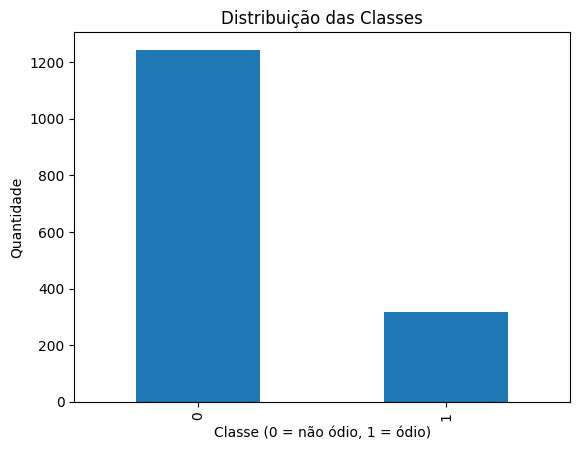

In [ ]:
# =========================
# 1. DISTRIBUIÇÃO DAS CLASSES
# =========================
print("\n===== DISTRIBUIÇÃO DAS CLASSES =====")
print(df['label'].value_counts())
print("\nPercentual:")
print(df['label'].value_counts(normalize=True) * 100)

df['label'].value_counts().plot(kind='bar')
plt.title("Distribuição das Classes")
plt.xlabel("Classe (0 = não ódio, 1 = ódio)")
plt.ylabel("Quantidade")
plt.show()


===== TAMANHO DOS TEXTOS =====
count    1561.000000
mean       33.003203
std         8.637982
min        16.000000
25%        25.000000
50%        32.000000
75%        40.000000
max        57.000000
Name: num_words, dtype: float64


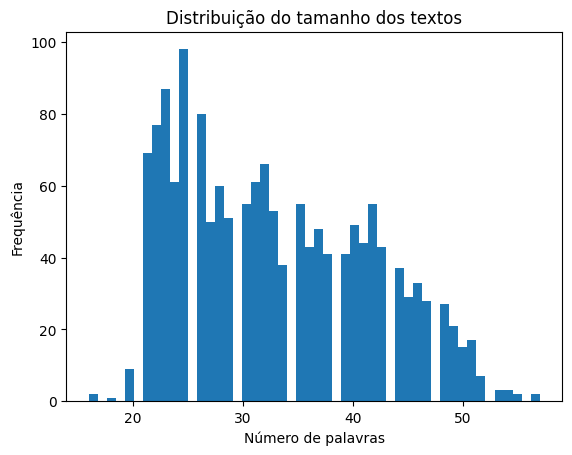

In [ ]:
# =========================
# 2. TAMANHO DOS TEXTOS
# =========================
df['num_words'] = df['text'].apply(lambda x: len(str(x).split()))

print("\n===== TAMANHO DOS TEXTOS =====")
print(df['num_words'].describe())

plt.hist(df['num_words'], bins=50)
plt.title("Distribuição do tamanho dos textos")
plt.xlabel("Número de palavras")
plt.ylabel("Frequência")
plt.show()

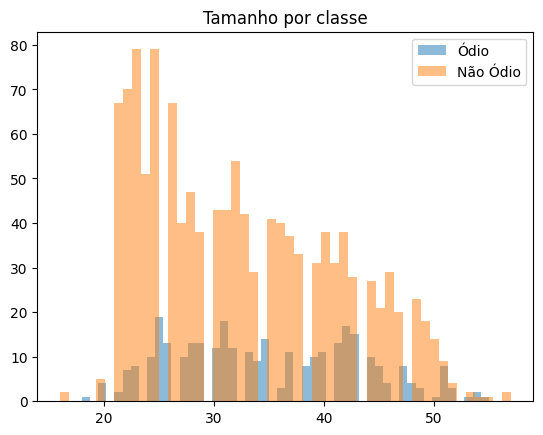

In [ ]:
# comparação por classe
plt.hist(df[df['label']==1]['num_words'], bins=50, alpha=0.5, label="Ódio")
plt.hist(df[df['label']==0]['num_words'], bins=50, alpha=0.5, label="Não Ódio")
plt.legend()
plt.title("Tamanho por classe")
plt.show()

In [ ]:
# =========================
# 4. PALAVRAS MAIS FREQUENTES
# =========================
def top_words(texts, n=20):
    words = " ".join(texts).split()
    return Counter(words).most_common(n)

print("\n===== TOP PALAVRAS =====")

print("\nÓDIO:")
print(top_words(df[df['label']==1]['text']))

print("\nNÃO ÓDIO:")
print(top_words(df[df['label']==0]['text']))


===== TOP PALAVRAS =====

ÓDIO:
[('de', 359), ('que', 307), ('o', 256), ('e', 250), ('em', 216), ('a', 207), ('Brasília', 147), ('do', 127), ('não', 121), ('é', 120), ('os', 94), ('para', 93), ('O', 88), ('no', 80), ('pra', 78), ('da', 71), ('com', 70), ('se', 69), ('um', 62), ('na', 53)]

NÃO ÓDIO:
[('de', 1329), ('que', 1199), ('e', 1022), ('o', 998), ('em', 960), ('a', 934), ('do', 560), ('Brasília', 536), ('não', 442), ('é', 435), ('da', 386), ('os', 376), ('para', 318), ('com', 292), ('O', 264), ('um', 264), ('se', 257), ('no', 235), ('dos', 218), ('na', 199)]


In [ ]:
# =========================
# 5. BIGRAMAS
# =========================
def top_bigrams(texts, n=10):
    words = " ".join(texts).split()
    bigrams = list(ngrams(words, 2))
    return Counter(bigrams).most_common(n)

print("\n===== BIGRAMAS =====")

print("\nÓDIO:")
print(top_bigrams(df[df['label']==1]['text']))

print("\nNÃO ÓDIO:")
print(top_bigrams(df[df['label']==0]['text']))


===== BIGRAMAS =====

ÓDIO:
[(('em', 'Brasília'), 80), (('o', 'que'), 24), (('que', 'o'), 23), (('em', 'Brasília.'), 22), (('de', 'Brasília'), 19), (('em', 'Brasília,'), 17), (('Brasília', 'e'), 16), (('é', 'o'), 14), (('que', 'não'), 14), (('o', 'povo'), 13)]

NÃO ÓDIO:
[(('em', 'Brasília'), 291), (('em', 'Brasília.'), 125), (('em', 'Brasília,'), 116), (('o', 'que'), 105), (('hoje', 'em'), 78), (('que', 'o'), 75), (('de', 'Brasília'), 71), (('Brasília', 'e'), 70), (('e', 'o'), 56), (('e', 'a'), 48)]


In [ ]:
# =========================
# 6. EXEMPLOS REAIS
# =========================
print("\n===== EXEMPLOS =====")

print("\nÓDIO:")
print(df[df['label']==1]['text'].sample(5))

print("\nNÃO ÓDIO:")
print(df[df['label']==0]['text'].sample(5))


===== EXEMPLOS =====

ÓDIO:
37       Dr Flávio Dino eu autorizo põe todos na cadei...
426      INFILTRADA \nEssa sra e seu marido Dom querem...
267     Acordar cedo e vê que tem idiota indo pra Bras...
1235    É simples: o mal quando não é cortado na raiz ...
883     Os índios que estão lá apoiando o governo são ...
Name: text, dtype: object

NÃO ÓDIO:
653      Já tinham vários grupos no telegram, eles faz...
681     Bora vigiar e punir...mas eu quero os empresár...
461        quer conhecer os culpados: Alexandre de Mor...
739     Ow , não gosto de fofoca, mas sabia que tem um...
1077    Duas fotos de Brasilia que estão rodando o mun...
Name: text, dtype: object


In [ ]:
# =========================
# 7. OUTLIERS
# =========================
print("\n===== MAIORES TEXTOS =====")
print(df.sort_values(by="num_words", ascending=False)[['text','num_words']].head(5))


===== MAIORES TEXTOS =====
                                                   text  num_words
1074   Você que vem dizer que eu te ameacei do qual ...         57
66     A pauta em favor dos entregadores é legítima ...         57
1363   Qual a droga q vc usa, deve ser forte né? Car...         55
931   O pau já tá quebrando e vcs ainda querem ir pr...         55
117     Mas como vc afirma ao general que fizeram de...         54


In [ ]:
# Divisão do dataset (72% treino, 8% validação e 20% teste)
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, stratify=train_df['label'], random_state=42)

print(len(train_df), len(val_df), len(test_df))

1123 125 313


In [ ]:
# Preparar entrada para o modelo (tokenização)
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding=True,
        truncation=True,
        max_length=128
    )

In [ ]:
# Criar dataset para treino
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

In [ ]:
# Criar modelo baseline (Bert)
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "neuralmind/bert-base-portuguese-cased",
    num_labels=2
)

In [ ]:
# Treinamento
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()
# OVERFITTING

In [ ]:
# Avaliação (precisio, recall, f1-score)
from sklearn.metrics import classification_report

predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = test_dataset['label']

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       249
           1       0.55      0.36      0.43        64

    accuracy                           0.81       313
   macro avg       0.70      0.64      0.66       313
weighted avg       0.79      0.81      0.79       313



In [ ]:
!pip install transformers torch scikit-learn networkx torch-geometric

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

In [ ]:
# Carregar Bert
tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")
bert_model = AutoModel.from_pretrained("neuralmind/bert-base-portuguese-cased")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()

In [ ]:
# Gerar Embeddings
embeddings = []

batch_size = 32

for i in range(0, len(df), batch_size):
    batch_texts = df['text'][i:i+batch_size].tolist()

    inputs = tokenizer(
        batch_texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = bert_model(**inputs)

    cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    embeddings.extend(cls_embeddings)

embeddings = np.array(embeddings)

print("Embeddings:", embeddings.shape)

Embeddings: (1561, 768)


In [ ]:
# Criar arestas
similarity_matrix = cosine_similarity(embeddings)

edges = []
threshold = 0.8  # ajuste depois

for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        if similarity_matrix[i][j] > threshold:
            edges.append((i, j))

print("Número de arestas:", len(edges))

Número de arestas: 127181


In [ ]:
# Criar Grafo
G = nx.Graph()

# nós
for i in range(len(df)):
    G.add_node(i,
               text=df['text'].iloc[i],
               label=int(df['label'].iloc[i]))

# arestas
G.add_edges_from(edges)

print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())

Nós: 1561
Arestas: 127181


Nós (sem isolados): 1501
Arestas: 127181
Maior componente - nós: 1489
Maior componente - arestas: 127175


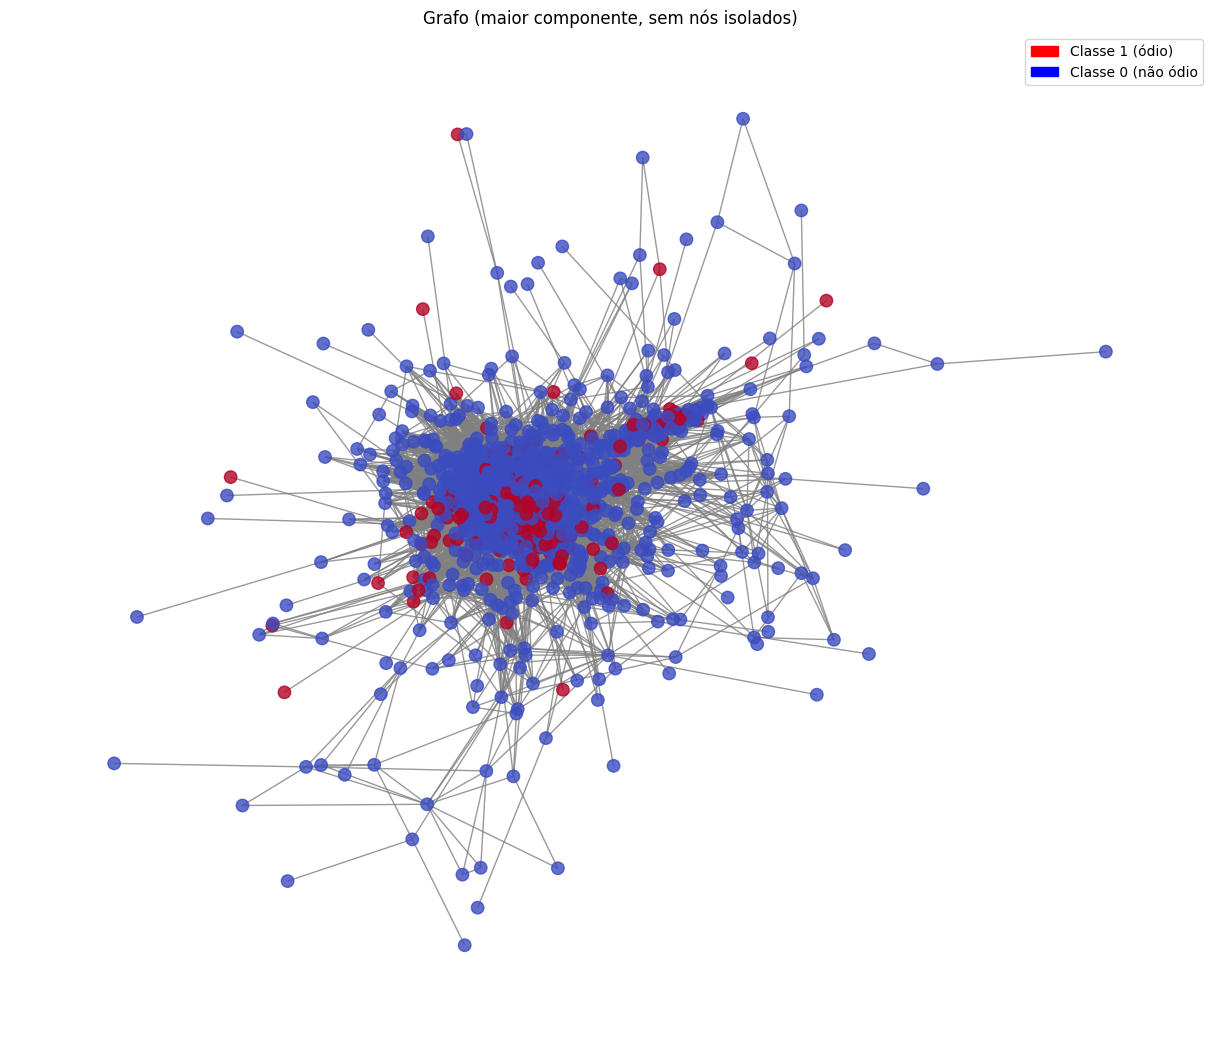

In [ ]:
# ================================
# 1. IMPORTS
# ================================
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ================================
# 2. REMOVER NÓS ISOLADOS
# ================================
G_clean = G.copy()

isolated_nodes = list(nx.isolates(G_clean))
G_clean.remove_nodes_from(isolated_nodes)

print("Nós (sem isolados):", G_clean.number_of_nodes())
print("Arestas:", G_clean.number_of_edges())

# ================================
# 3. PEGAR MAIOR COMPONENTE
# ================================
largest_cc = max(nx.connected_components(G_clean), key=len)
G_main = G_clean.subgraph(largest_cc).copy()

print("Maior componente - nós:", G_main.number_of_nodes())
print("Maior componente - arestas:", G_main.number_of_edges())

# ================================
# 4. CRIAR CORES
# ================================
colors = [G_main.nodes[n]['label'] for n in G_main.nodes()]

# ================================
# 5. DEFINIR LAYOUT (MELHORADO)
# ================================
pos = nx.spring_layout(
    G_main,
    k=0.4,           # espaçamento (ajuste se quiser)
    iterations=50,
    seed=42
)

# ================================
# 6. PLOTAR GRAFO
# ================================
plt.figure(figsize=(12, 10))

nx.draw(
    G_main,
    pos,
    node_size=80,
    node_color=colors,
    cmap=plt.cm.coolwarm,
    edge_color="gray",
    alpha=0.8,
    with_labels=False
)

# ================================
# 7. LEGENDA
# ================================
import matplotlib.patches as mpatches

red_patch = mpatches.Patch(color='red', label='Classe 1 (ódio)')
blue_patch = mpatches.Patch(color='blue', label='Classe 0 (não ódio')

plt.legend(handles=[red_patch, blue_patch])

plt.title("Grafo (maior componente, sem nós isolados)")
plt.show()

Número de arestas: 6461
Nós: 1561
Arestas: 6461
Nós (limpo): 1561
Arestas (limpo): 6461


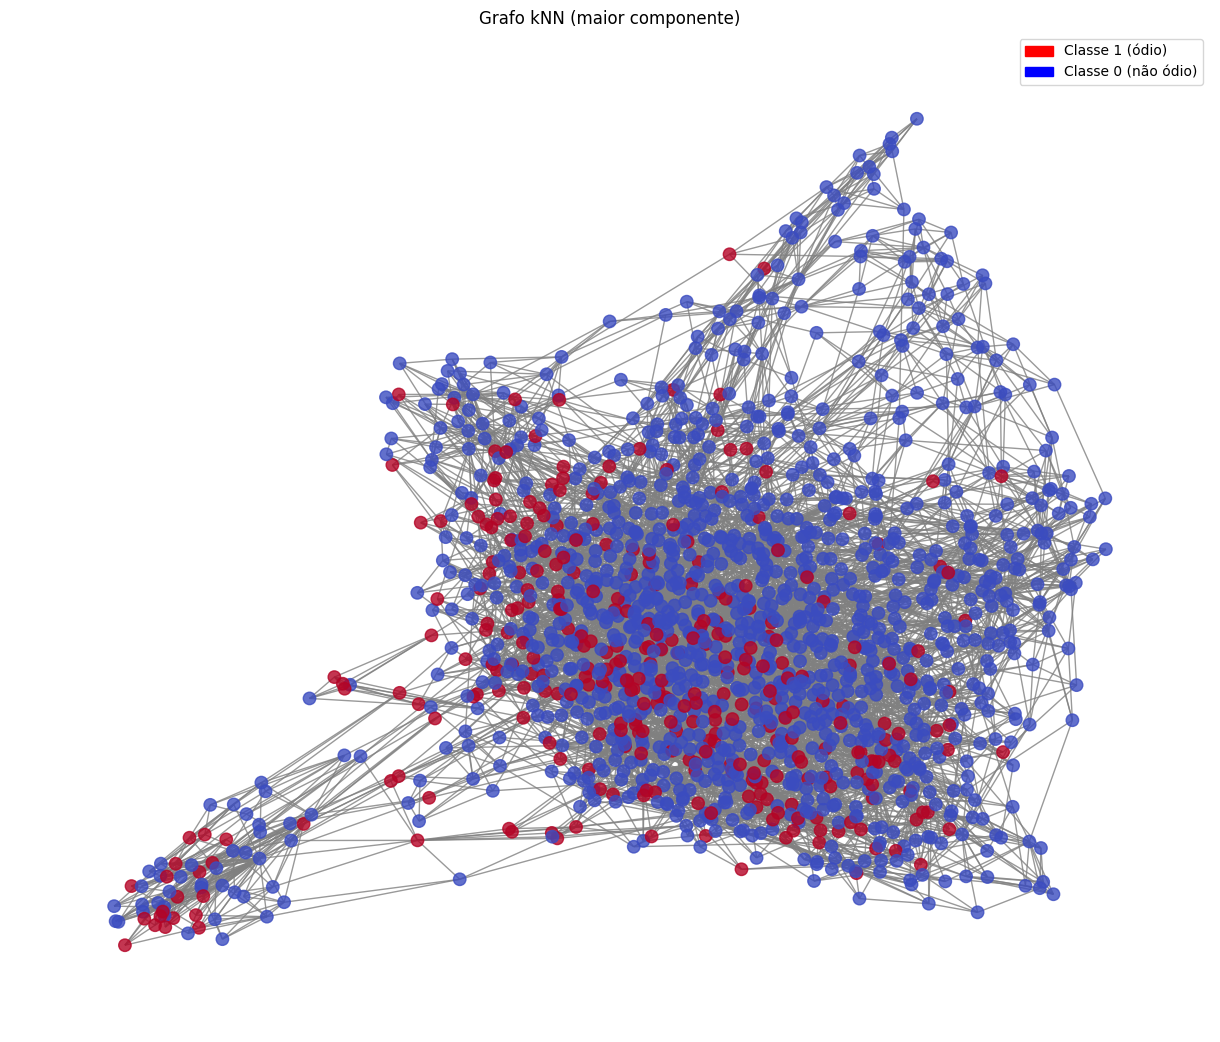

Data(x=[1561, 768], edge_index=[2, 6461], y=[1561])
Shape X: torch.Size([1561, 768])
Shape edge_index: torch.Size([2, 6461])
Shape y: torch.Size([1561])


In [ ]:
# kNN + GRAFO + VISUALIZAÇÃO + PyG
# =========================================
# 1. IMPORTS
# =========================================
!pip install scikit-learn networkx torch-geometric

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from sklearn.neighbors import NearestNeighbors

# =========================================
# 2. CRIAR ARESTAS COM kNN
# =========================================
k = 5

nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine')
nbrs.fit(embeddings)

distances, indices = nbrs.kneighbors(embeddings)

edges = set()

for i in range(len(indices)):
    for j in indices[i]:
        if i != j:
            edge = tuple(sorted((i, j)))
            edges.add(edge)

edges = list(edges)

print("Número de arestas:", len(edges))

# =========================================
# 3. CRIAR GRAFO
# =========================================
G_knn = nx.Graph()

for i in range(len(df)):
    G_knn.add_node(
        i,
        text=df['text'].iloc[i],
        label=int(df['label'].iloc[i])
    )

G_knn.add_edges_from(edges)

print("Nós:", G_knn.number_of_nodes())
print("Arestas:", G_knn.number_of_edges())

# =========================================
# 4. LIMPAR GRAFO (remover isolados)
# =========================================
G_clean = G_knn.copy()
G_clean.remove_nodes_from(list(nx.isolates(G_clean)))

# maior componente
largest_cc = max(nx.connected_components(G_clean), key=len)
G_main = G_clean.subgraph(largest_cc).copy()

print("Nós (limpo):", G_main.number_of_nodes())
print("Arestas (limpo):", G_main.number_of_edges())

# =========================================
# 5. VISUALIZAÇÃO MELHORADA
# =========================================
colors = [G_main.nodes[n]['label'] for n in G_main.nodes()]

pos = nx.spring_layout(G_main, k=0.4, iterations=50, seed=42)

plt.figure(figsize=(12, 10))

nx.draw(
    G_main,
    pos,
    node_size=80,
    node_color=colors,
    cmap=plt.cm.coolwarm,
    edge_color="gray",
    alpha=0.8,
    with_labels=False
)

# legenda
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Classe 1 (ódio)')
blue_patch = mpatches.Patch(color='blue', label='Classe 0 (não ódio)')

plt.legend(handles=[red_patch, blue_patch])
plt.title("Grafo kNN (maior componente)")
plt.show()

# =========================================
# 6. CONVERTER PARA PYTORCH GEOMETRIC
# =========================================
from torch_geometric.data import Data

x = torch.tensor(embeddings, dtype=torch.float)
y = torch.tensor(df['label'].values, dtype=torch.long)

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

data_knn = Data(x=x, edge_index=edge_index, y=y)

print(data_knn)

# shapes
print("Shape X:", data_knn.x.shape)
print("Shape edge_index:", data_knn.edge_index.shape)
print("Shape y:", data_knn.y.shape)